In [1]:
import os
os.chdir("..")
data = 'data'

In [2]:
path = os.path.join(os.getcwd(), data)
band_dir = os.path.join(path, 'images')
mask_dir = os.path.join(path, 'masks')

In [3]:
import glob
import rasterio
from rasterio.merge import merge

In [4]:
band_files = glob.glob(f"{band_dir}/*.tif")
mask_files = glob.glob(f"{mask_dir}/*.tif")

In [5]:
bands = [rasterio.open(f) for f in band_files]
masks = [rasterio.open(f) for f in mask_files]

In [6]:
img_mosaic, img_transform = merge(bands)
mask_mosaic, mask_transform = merge(masks)

In [7]:
print(img_mosaic.shape)
print(mask_mosaic.shape)

(7, 8869, 16236)
(1, 8869, 16236)


In [9]:
assert img_transform == mask_transform

In [10]:
img_transform

Affine(10.0, 0.0, 8564020.0,
       0.0, -10.0, 4143730.0)

In [11]:
mask_transform

Affine(10.0, 0.0, 8564020.0,
       0.0, -10.0, 4143730.0)

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
rgb = np.stack([
        img_mosaic[2],
        img_mosaic[1],
        img_mosaic[0]
    ], axis=-1).astype('float32')
print(rgb.shape)
rgb = (rgb - rgb.min(axis=(0, 1))) / (rgb.max(axis=(0, 1)) - rgb.min(axis=(0, 1)))

(8869, 16236, 3)


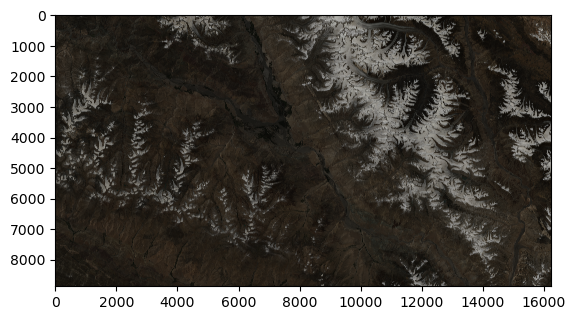

In [14]:
plt.imshow(rgb)
plt.show()

In [7]:
import numpy as np
import xdem
from scipy.ndimage import gaussian_filter

with rasterio.open(band_files[0]) as src:
    transform = src.transform
    crs = src.crs

# -----------------------------
# Extract DEM
# -----------------------------

dem = img_mosaic[6]

# -----------------------------
# Smooth DEM
# -----------------------------
# Reduces noise in curvature

dem = gaussian_filter(dem, sigma=1)

# -----------------------------
# Convert to xDEM object
# -----------------------------

dem_x = xdem.DEM.from_array(dem, transform=transform, crs=crs)

# -----------------------------
# First order terrain
# -----------------------------

slope = xdem.terrain.slope(dem_x)
aspect = xdem.terrain.aspect(dem_x)

slope = slope.data
aspect = aspect.data


# Convert aspect for ML

aspect_rad = np.deg2rad(aspect)

aspect_sin = np.sin(aspect_rad)
aspect_cos = np.cos(aspect_rad)

# -----------------------------
# Curvature metrics from xDEM
# -----------------------------

profile_curv = xdem.terrain.profile_curvature(dem_x)
plan_curv = xdem.terrain.planform_curvature(dem_x)
profile_curv = profile_curv.data
plan_curv = plan_curv.data

# -----------------------------
# Manual second derivatives
# -----------------------------

dx, dy = np.gradient(dem, 10, 10)

dxx, dxy = np.gradient(dx, 10, 10)
dyx, dyy = np.gradient(dy, 10, 10)

# -----------------------------
# Mean curvature
# -----------------------------

mean_curv = (dxx + dyy) / 2


# -----------------------------
# Gaussian curvature
# -----------------------------

gaussian_curv = (dxx * dyy - dxy**2)


# -----------------------------
# Slope azimuth divergence
# -----------------------------

slope_azimuth_divergence = dxx + dyy


# -----------------------------
# Unsphericity
# -----------------------------

unsphericity = np.sqrt(dxx**2 + 2*(dxy**2) + dyy**2)

In [8]:
print(type(slope), type(aspect_sin), type(aspect_cos), type(profile_curv), type(plan_curv))

<class 'numpy.ma.core.MaskedArray'> <class 'numpy.ma.core.MaskedArray'> <class 'numpy.ma.core.MaskedArray'> <class 'numpy.ma.core.MaskedArray'> <class 'numpy.ma.core.MaskedArray'>


In [9]:
slope = np.ma.filled(slope, 0)
profile_curv = np.ma.filled(profile_curv, 0)
plan_curv = np.ma.filled(plan_curv, 0)
aspect_sin = np.ma.filled(aspect_sin, 0)
aspect_cos = np.ma.filled(aspect_cos, 0)

In [10]:
PATCH = 512
STRIDE = 512

In [13]:
_, H, W = img_mosaic.shape

In [15]:
mask_mosaic.shape

(1, 8869, 16236)

In [16]:
os.makedirs("dataset/images", exist_ok=True)
os.makedirs("dataset/masks", exist_ok=True)

counter = 0

for y in range(0, H - PATCH + 1, STRIDE):
    for x in range(0, W - PATCH + 1, STRIDE):

        # -----------------------------
        # Spectral bands (6) + DEM (1)
        # -----------------------------
        img_patch = img_mosaic[:, y:y+PATCH, x:x+PATCH]

        # -----------------------------
        # Terrain derivatives
        # -----------------------------
        terrain_patch = np.stack([
            slope[y:y+PATCH, x:x+PATCH],
            aspect_sin[y:y+PATCH, x:x+PATCH],
            aspect_cos[y:y+PATCH, x:x+PATCH],
            profile_curv[y:y+PATCH, x:x+PATCH],
            plan_curv[y:y+PATCH, x:x+PATCH],
            mean_curv[y:y+PATCH, x:x+PATCH],
            gaussian_curv[y:y+PATCH, x:x+PATCH],
            slope_azimuth_divergence[y:y+PATCH, x:x+PATCH],
            unsphericity[y:y+PATCH, x:x+PATCH]
        ])

        # -----------------------------
        # Combine spectral + terrain
        # -----------------------------
        full_patch = np.concatenate([img_patch, terrain_patch], axis=0)
        print(type(full_patch))

        # -----------------------------
        # Ground truth mask
        # -----------------------------
        mask_patch = mask_mosaic[:, y:y+PATCH, x:x+PATCH]

        # -----------------------------
        # Optional filtering
        # Skip mostly empty patches
        # -----------------------------
        if mask_patch.sum() < 50:
            continue

        # -----------------------------
        # Patch index
        # -----------------------------
        r = y // PATCH
        c = x // PATCH

        # -----------------------------
        # Save patch
        # -----------------------------
        np.save(f"dataset/images/img_r{r}_c{c}.npy", full_patch.astype(np.float32))
        np.save(f"dataset/masks/mask_r{r}_c{c}.npy", mask_patch.astype(np.uint8))

        counter += 1


print("Saved patches:", counter)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.nd